In [2]:
import pandas as pd


![alt text](cols_def.png)

In [ ]:
df = pd.read_csv("../Data/cs-training.csv")
df

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [5]:
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [1]:
import pandas as pd
import numpy as np
import os

# ---------------- CONFIGURACIÓN ----------------
n_samples = 10000
output_file = "data/credit_data.csv"
# ------------------------------------------------

# Crear directorio de salida
os.makedirs("data", exist_ok=True)

# Generación reproducible
np.random.seed(42)

# Crear variables sintéticas
data = pd.DataFrame({
    "client_id": np.arange(1, n_samples + 1),
    "age": np.random.randint(21, 65, size=n_samples),
    "income": np.random.normal(40000, 12000, size=n_samples).clip(min=5000).astype(int),
    "employment_years": np.random.randint(0, 35, size=n_samples),
    "loan_amount": np.random.randint(1000, 20000, size=n_samples),
    "credit_history_length": np.random.randint(1, 15, size=n_samples),
    "num_credit_lines": np.random.randint(1, 10, size=n_samples),
    "late_payments": np.random.poisson(1.2, size=n_samples),
    "region": np.random.choice(["North", "South", "East", "West"], size=n_samples),
    "has_dependents": np.random.choice([0, 1], size=n_samples),
})

# Simular probabilidad de default
logit = (
    -0.02 * data["age"]
    - 0.00004 * data["income"]
    + 0.05 * (data["loan_amount"] / 1000)
    + 0.2 * data["late_payments"]
    + 0.1 * (data["employment_years"] < 2).astype(int)
    + 0.3 * data["has_dependents"]
)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Aplicar función logística para obtener probabilidad
default_prob = sigmoid(logit)

# Asignar default binario según esa probabilidad
data["default"] = np.random.binomial(1, default_prob)


In [2]:
data

,client_id,age,income,employment_years,loan_amount,credit_history_length,num_credit_lines,late_payments,region,has_dependents,default
0,1,59,38526,0,17308,6,4,5,South,0,0
1,2,49,37408,4,12849,5,7,0,East,0,0
2,3,35,37948,10,16317,4,7,1,East,1,0
3,4,63,61962,9,13341,13,6,1,South,1,0
4,5,28,26863,14,14778,2,7,0,North,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,29,42643,1,7436,8,1,1,South,0,1
9996,9997,37,21616,10,7840,9,6,2,South,0,0
9997,9998,56,60414,30,10872,9,8,1,West,1,0
9998,9999,37,49121,12,5850,14,4,0,South,1,0


In [3]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import shap
import matplotlib.pyplot as plt
import os

c:\Users\usuario\anaconda3\envs\TFM_MUGRF\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:31:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\usuario\AppData\Local\Temp\ipykernel_22296\1253156599.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/shap_summary_bar.png'

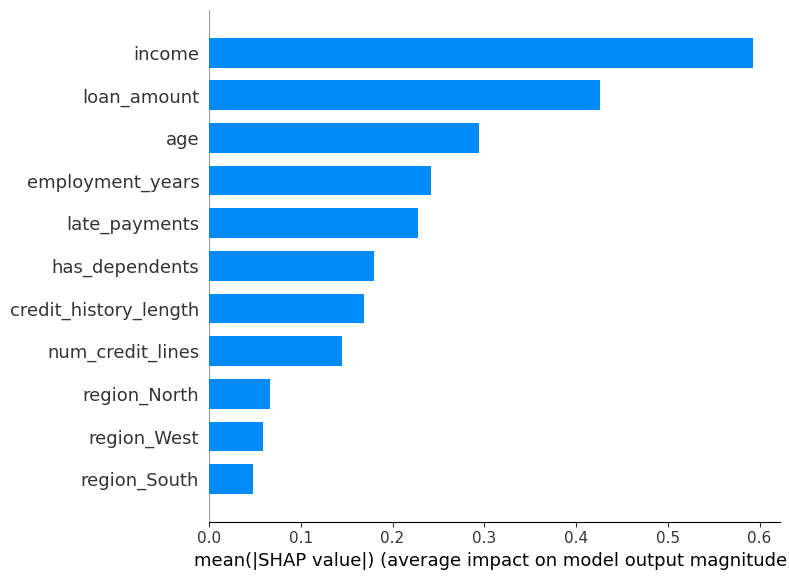

In [4]:
# One-hot encoding para variable categórica 'region'
data = pd.get_dummies(data, columns=["region"], drop_first=True)

# Preparar datos para XGBoost
X = data.drop(columns=["client_id", "default"])
y = data["default"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar modelo XGBoost
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

# Evaluar modelo
y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred, output_dict=True)
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

# Aplicar SHAP
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Gráficos SHAP
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("/mnt/data/shap_summary_bar.png")
plt.close()

plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("/mnt/data/shap_summary_dot.png")
plt.close()